In [10]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [11]:
import os
import sys
from pathlib import Path

# check if workding_dir is in local variables
if "workding_dir" not in locals():
    workding_dir = str(Path.cwd().parent)

os.chdir(workding_dir)
sys.path.append(workding_dir)
print("workding dir:", workding_dir)

workding dir: /Users/inflaton/code/engd/papers/multi-agent-llm-at-edge


In [12]:
from dotenv import find_dotenv, load_dotenv
from src.misc.metrics import *

found_dotenv = find_dotenv(".env")

if len(found_dotenv) == 0:
    found_dotenv = find_dotenv(".env.example")
print(f"loading env vars from: {found_dotenv}")
load_dotenv(found_dotenv, override=True)

loading env vars from: /Users/inflaton/code/engd/papers/multi-agent-llm-at-edge/.env


True

In [13]:
%%time

result_folder = "results/OpenAI/o4-mini-o4-mini"

db_filepath = f"{result_folder}/emails.db"
metrics = calculate_metrics(db_filepath)
df = metrics["df"]
del metrics["df"]
metrics

CPU times: user 7min 59s, sys: 5min 42s, total: 13min 42s
Wall time: 1min 19s


{'task_completion_rate': 1,
 'task_success_rate': 0.9611111111111111,
 'total_execution_time': 63885.173560999996,
 'mean_execution_time': 32.26523917222222,
 'std_execution_time': 24.42367295275529,
 'mean_process_steps': 9.019191919191918,
 'std_process_steps': 5.275304555582927,
 'total_tasks': 1980,
 'SUCCESS': 1903,
 'DB_UPDATE_TOOL_NOT_INITIALIZED': 77}

In [14]:
df.head(5)

,email_id,sender_email,recipient_email,subject,email_body,attachments,process_status,response,start_time,end_time,...,successful_requests,total_tokens,prompt_tokens,completion_tokens,total_cost,original_process_status,process_steps,ocr_bert_f1,duration,duration_hms
0,93185A89130149C0A842968E4AFDCAA2,RobinLevine@example.com,tanya.official.456@gmail.com,Payment Confirmation for Invoice ID: 43925,Hi Tanya ! Please find attached payment screen...,transaction_1.jpeg,SUCCESS,"{""content"": ""DONE""}",2025-04-17 05:36:26.825168,2025-04-17 05:36:56.434467,...,6,4399,1890,2509,0.0,SUCCESS,9,0.913878,29.609299,0 days 00:00:29
1,614972488B7B411BAEA4814CF066CDAA,StevenNixon@example.com,tanya.official.456@gmail.com,Payment Confirmation for Invoice ID: 51782,Hi Tanya ! Please find attached payment screen...,transaction_2.jpeg,SUCCESS,"{""content"": ""DONE""}",2025-04-17 05:36:56.440256,2025-04-17 05:37:35.623811,...,6,4478,1886,2592,0.0,SUCCESS,9,0.908642,39.183555,0 days 00:00:39
2,C484ABEB38F44D29960B1CEF58510627,MadisonFord@example.com,tanya.official.456@gmail.com,Payment Confirmation for Invoice ID: 42968,Hi Tanya ! Please find attached payment screen...,transaction_3.jpeg,SUCCESS,"{""content"": ""DONE""}",2025-04-17 05:37:35.629095,2025-04-17 05:38:04.025896,...,6,4510,1877,2633,0.0,SUCCESS,9,0.941656,28.396801,0 days 00:00:28
3,706B3403E8024178948B3BFBF9E64A25,KathrynJones@example.com,tanya.official.456@gmail.com,Payment Confirmation for Invoice ID: 92948,Hi Tanya ! Please find attached payment screen...,transaction_4.jpeg,SUCCESS,"{""content"": ""DONE""}",2025-04-17 05:38:04.030963,2025-04-17 05:38:32.567561,...,6,4986,1813,3173,0.0,SUCCESS,9,0.942956,28.536598,0 days 00:00:28
4,86838440CA6C472AACFA3FCE1382609C,ChristineOwens@example.com,tanya.official.456@gmail.com,Payment Confirmation for Invoice ID: 20304,Hi Tanya ! Please find attached payment screen...,transaction_5.jpeg,SUCCESS,"{""content"": ""DONE""}",2025-04-17 05:38:32.572306,2025-04-17 05:39:06.984335,...,6,4729,1877,2852,0.0,SUCCESS,9,0.938928,34.412029,0 days 00:00:34


In [15]:
df[df["attachments"] != ""]["ocr_bert_f1"].describe()

count    990.000000
mean       0.939822
std        0.015261
min        0.902572
25%        0.927554
50%        0.940874
75%        0.949427
max        0.980198
Name: ocr_bert_f1, dtype: float64

In [16]:
import matplotlib.pyplot as plt


def plot_value_distribution(df_filtered, col="category", top_n=10):
    df_filtered[col].value_counts()[:top_n].plot(kind="bar")
    plt.title(f"Distribution of {col}")

    # add the count on top of the bars
    for i in range(len(df_filtered[col].value_counts()[:top_n])):
        count = df_filtered[col].value_counts().values[i]
        plt.text(i, count, count, ha="center")

    plt.show()

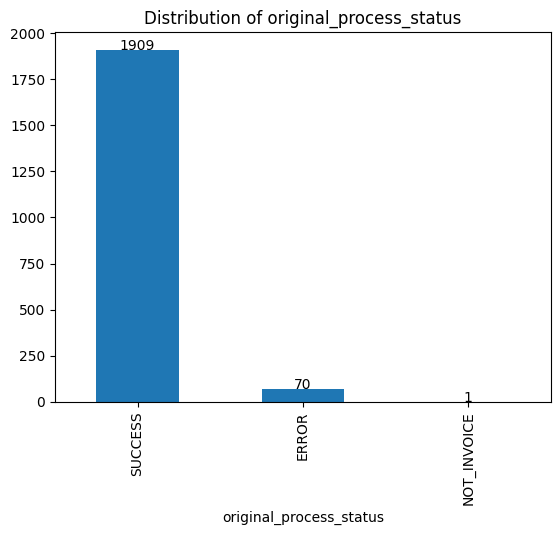

In [17]:
plot_value_distribution(df, "original_process_status")

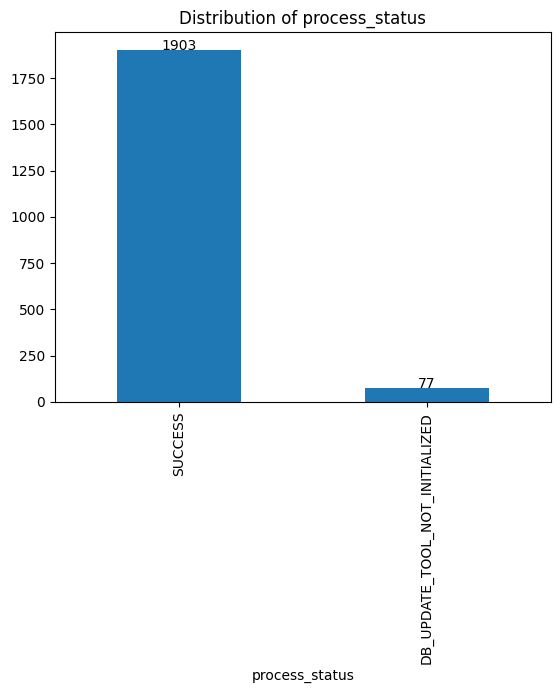

In [18]:
plot_value_distribution(df, "process_status")

In [19]:
print_row_details(df, [0])

--------------------------------------------------
email_id: 93185A89130149C0A842968E4AFDCAA2
--------------------------------------------------
sender_email: RobinLevine@example.com
--------------------------------------------------
recipient_email: tanya.official.456@gmail.com
--------------------------------------------------
subject: Payment Confirmation for Invoice ID: 43925
--------------------------------------------------
email_body: Hi Tanya ! Please find attached payment screenshot for Invoice ID: 43925 , Regards Robin Levine
--------------------------------------------------
attachments: transaction_1.jpeg
--------------------------------------------------
process_status: SUCCESS
--------------------------------------------------
response: {"content": "DONE"}
--------------------------------------------------
start_time: 2025-04-17 05:36:26.825168
--------------------------------------------------
end_time: 2025-04-17 05:36:56.434467
-----------------------------------------

In [20]:
import json

logs = json.loads(df.iloc[0]["full_logs"])
len(logs)

9

In [21]:
for log in logs:
    # pretty print the log json
    print(json.dumps(log, indent=4))
    print("===" * 20)

{
    "name": "input",
    "type": "HumanMessage",
    "content": "\n                Help to reconcile invoices using the following email:\n\n                \n            Sender: RobinLevine@example.com\n            Subject: Payment Confirmation for Invoice ID: 43925\n            Body: Hi Tanya ! Please find attached payment screenshot for Invoice ID: 43925 , Regards Robin Levine\n            Attachment: transaction_1.jpeg\n            \n                ",
    "timestamp": "2025-04-17T05:36:26.825168",
    "usage": {
        "input_tokens": 0,
        "output_tokens": 0,
        "total_tokens": 0,
        "input_token_details": {
            "audio": 0,
            "cache_read": 0
        },
        "output_token_details": {
            "audio": 0,
            "reasoning": 0
        }
    },
    "model_name": "",
    "additional_kwargs": {}
}
{
    "name": "finance_clerk",
    "type": "AIMessage",
    "content": "Tool calls to ocr_tool",
    "timestamp": "2025-04-17T05:36:30.406504",


In [22]:
tool_call_logs = []
for log in logs:
    if log["name"] in ["ocr_tool", "invoice_db_query_tool", "invoice_db_update_tool"]:
        # pretty print the log json
        print(json.dumps(log, indent=4))
        print("===" * 20)
        tool_call_logs.append(log)
len(tool_call_logs)

{
    "name": "ocr_tool",
    "type": "ToolMessage",
    "content": "{\"content\": \"Bank 538  \\nSent by: Robin Levine  \\n\\n[check mark icon]  \\nYou paid $196  \\nto Tanya  \\n\\nTransaction Reference Number:  \\nEC4F9FE854344D25  \\nTransaction Date: 04/23/23  \\nInvoice ID: 43925\", \"usage\": {\"successful_requests\": 1, \"total_tokens\": 678, \"prompt_tokens\": 348, \"completion_tokens\": 330, \"total_cost\": 0.0}}",
    "timestamp": "2025-04-17T05:36:30.406504",
    "usage": {
        "input_tokens": 0,
        "output_tokens": 0,
        "total_tokens": 0,
        "input_token_details": {
            "audio": 0,
            "cache_read": 0
        },
        "output_token_details": {
            "audio": 0,
            "reasoning": 0
        }
    },
    "model_name": "",
    "additional_kwargs": {}
}
{
    "name": "invoice_db_query_tool",
    "type": "ToolMessage",
    "content": "{\"content\": {\"invoice_id\": \"43925\", \"bank_name\": \"Bank 538\", \"transaction_id\": \"EC

3

In [23]:
df["process_status"].value_counts()

process_status
SUCCESS                           1903
DB_UPDATE_TOOL_NOT_INITIALIZED      77
Name: count, dtype: int64

In [24]:
df_filtered = (
    df[df["process_status"] == "DB_UPDATE_TOOL_NOT_INITIALIZED"].copy().reset_index(drop=True)
)
len(df_filtered)

77

In [25]:
print_row_details(df_filtered, [0])

--------------------------------------------------
email_id: 34AA7A59847C4141B526E83794125CAD
--------------------------------------------------
sender_email: RobinAnderson@example.com
--------------------------------------------------
recipient_email: tanya.official.456@gmail.com
--------------------------------------------------
subject: Payment Confirmation for Invoice ID: 21369
--------------------------------------------------
email_body: Hi Tanya ! Please find attached payment screenshot for Invoice ID: 21369 , Regards Robin Anderson
--------------------------------------------------
attachments: transaction_44.jpeg
--------------------------------------------------
process_status: DB_UPDATE_TOOL_NOT_INITIALIZED
--------------------------------------------------
response: Understood. Awaiting the invoice details for Invoice ID 21369.
--------------------------------------------------
start_time: 2025-04-17 05:58:14.022539
--------------------------------------------------
end_tim

In [26]:
import json

logs = json.loads(df_filtered.iloc[0]["full_logs"])
len(logs)

7

In [27]:
for log in logs:
    # pretty print the log json
    print(json.dumps(log, indent=4))
    print("===" * 20)

{
    "name": "input",
    "type": "HumanMessage",
    "content": "\n                Help to reconcile invoices using the following email:\n\n                \n            Sender: RobinAnderson@example.com\n            Subject: Payment Confirmation for Invoice ID: 21369\n            Body: Hi Tanya ! Please find attached payment screenshot for Invoice ID: 21369 , Regards Robin Anderson\n            Attachment: transaction_44.jpeg\n            \n                ",
    "timestamp": "2025-04-17T05:58:14.022539",
    "usage": {
        "input_tokens": 0,
        "output_tokens": 0,
        "total_tokens": 0,
        "input_token_details": {
            "audio": 0,
            "cache_read": 0
        },
        "output_token_details": {
            "audio": 0,
            "reasoning": 0
        }
    },
    "model_name": "",
    "additional_kwargs": {}
}
{
    "name": "finance_clerk",
    "type": "AIMessage",
    "content": "Tool calls to ocr_tool",
    "timestamp": "2025-04-17T05:58:16.8201

In [28]:
tool_call_logs = []
for log in logs:
    if log["name"] in ["ocr_tool", "invoice_db_query_tool", "invoice_db_update_tool"]:
        # pretty print the log json
        print(json.dumps(log, indent=4))
        print("===" * 20)
        tool_call_logs.append(log)
len(tool_call_logs)

{
    "name": "ocr_tool",
    "type": "ToolMessage",
    "content": "{\"content\": \"Bank 789  \\nSent by: Robin Anderson  \\n\\n\u2713  \\n\\nYou paid $173  \\nto Tanya  \\n\\nTransaction Reference Number:  \\nCE01A265CA3A4BFF  \\n\\nTransaction Date: 07/22/24  \\n\\nInvoice ID: 21369\", \"usage\": {\"successful_requests\": 1, \"total_tokens\": 1379, \"prompt_tokens\": 348, \"completion_tokens\": 1031, \"total_cost\": 0.0}}",
    "timestamp": "2025-04-17T05:58:16.820115",
    "usage": {
        "input_tokens": 0,
        "output_tokens": 0,
        "total_tokens": 0,
        "input_token_details": {
            "audio": 0,
            "cache_read": 0
        },
        "output_token_details": {
            "audio": 0,
            "reasoning": 0
        }
    },
    "model_name": "",
    "additional_kwargs": {}
}
{
    "name": "invoice_db_query_tool",
    "type": "ToolMessage",
    "content": "{\"content\": {\"invoice_id\": \"21369\", \"bank_name\": \"Bank 789\", \"transaction_id\": \"

2

In [29]:
logs[-1]

{'name': 'senior_reconciliation_agent',
 'type': 'AIMessage',
 'content': 'Understood. Awaiting the invoice details for Invoice ID\xa021369.',
 'timestamp': '2025-04-17T05:58:35.922195',
 'usage': {'input_tokens': 420,
  'output_tokens': 482,
  'total_tokens': 902,
  'input_token_details': {'audio': 0, 'cache_read': 0},
  'output_token_details': {'audio': 0, 'reasoning': 448}},
 'model_name': 'o4-mini-2025-04-16',
 'additional_kwargs': {}}

In [30]:
from src.misc.metrics import *

db_filepath = f"{result_folder}/transactions.db"
query = "SELECT * FROM transactions WHERE invoice_id = 21369"

df_txn = run_sql_query(db_filepath, query)

len(df_txn)

1

In [31]:
print_row_details(df_txn)

--------------------------------------------------
invoice_id: 21369
--------------------------------------------------
bank_name: Bank 789
--------------------------------------------------
transaction_id: CE01A265CA3A4BFF
--------------------------------------------------
amount: 173.0
--------------------------------------------------
recipient_name: Tanya
--------------------------------------------------
sender_name: Robin Anderson
--------------------------------------------------
reconciliation_state: UNPAID
--------------------------------------------------
email_details: 


In [48]:
print_row_details(df_filtered, [3])

--------------------------------------------------
email_id: 7C00F8E6AFD346D682E96928FEA50B2D
--------------------------------------------------
sender_email: JacobJohnson@example.com
--------------------------------------------------
recipient_email: tanya.official.456@gmail.com
--------------------------------------------------
subject: Payment Confirmation for Invoice ID: 30242
--------------------------------------------------
email_body: Hi Tanya ! Please find attached payment screenshot for Invoice ID: 30242 , Regards Jacob Johnson
--------------------------------------------------
attachments: transaction_141.jpeg
--------------------------------------------------
process_status: DB_UPDATE_TOOL_NOT_INITIALIZED
--------------------------------------------------
response: ERROR Transaction reference number mismatch: OCR shows “CE21BBD12AEE4D3F” but the database record for invoice 30242 shows “CE218BD12AEE4D3F.”
--------------------------------------------------
start_time: 2025-04

In [33]:
import json

logs = json.loads(df_filtered.iloc[3]["full_logs"])
len(logs)

7

In [34]:
for log in logs:
    # pretty print the log json
    print(json.dumps(log, indent=4))
    print("===" * 20)

{
    "name": "input",
    "type": "HumanMessage",
    "content": "\n                Help to reconcile invoices using the following email:\n\n                \n            Sender: JacobJohnson@example.com\n            Subject: Payment Confirmation for Invoice ID: 30242\n            Body: Hi Tanya ! Please find attached payment screenshot for Invoice ID: 30242 , Regards Jacob Johnson\n            Attachment: transaction_141.jpeg\n            \n                ",
    "timestamp": "2025-04-17T06:49:40.964484",
    "usage": {
        "input_tokens": 0,
        "output_tokens": 0,
        "total_tokens": 0,
        "input_token_details": {
            "audio": 0,
            "cache_read": 0
        },
        "output_token_details": {
            "audio": 0,
            "reasoning": 0
        }
    },
    "model_name": "",
    "additional_kwargs": {}
}
{
    "name": "finance_clerk",
    "type": "AIMessage",
    "content": "Tool calls to ocr_tool",
    "timestamp": "2025-04-17T06:49:46.10825

In [35]:
tool_call_logs = []
for log in logs:
    if log["name"] in ["ocr_tool", "invoice_db_query_tool", "invoice_db_update_tool"]:
        # pretty print the log json
        print(json.dumps(log, indent=4))
        print("===" * 20)
        tool_call_logs.append(log)
len(tool_call_logs)

{
    "name": "ocr_tool",
    "type": "ToolMessage",
    "content": "{\"content\": \"Bank 560  \\nSent by: Jacob Johnson  \\n\\nYou paid $111  \\nto Tanya  \\n\\nTransaction Reference Number:  \\nCE21BBD12AEE4D3F  \\nTransaction Date: 04/03/23  \\nInvoice ID: 30242\", \"usage\": {\"successful_requests\": 1, \"total_tokens\": 738, \"prompt_tokens\": 348, \"completion_tokens\": 390, \"total_cost\": 0.0}}",
    "timestamp": "2025-04-17T06:49:46.108251",
    "usage": {
        "input_tokens": 0,
        "output_tokens": 0,
        "total_tokens": 0,
        "input_token_details": {
            "audio": 0,
            "cache_read": 0
        },
        "output_token_details": {
            "audio": 0,
            "reasoning": 0
        }
    },
    "model_name": "",
    "additional_kwargs": {}
}
{
    "name": "invoice_db_query_tool",
    "type": "ToolMessage",
    "content": "{\"content\": {\"invoice_id\": \"30242\", \"bank_name\": \"Bank 560\", \"transaction_id\": \"CE218BD12AEE4D3F\", \"a

2

In [36]:
logs[-1]

{'name': 'senior_reconciliation_agent',
 'type': 'AIMessage',
 'content': 'ERROR Transaction reference number mismatch: OCR shows “CE21BBD12AEE4D3F” but the database record for invoice\xa030242 shows “CE218BD12AEE4D3F.”',
 'timestamp': '2025-04-17T06:50:08.299113',
 'usage': {'input_tokens': 418,
  'output_tokens': 638,
  'total_tokens': 1056,
  'input_token_details': {'audio': 0, 'cache_read': 0},
  'output_token_details': {'audio': 0, 'reasoning': 576}},
 'model_name': 'o4-mini-2025-04-16',
 'additional_kwargs': {}}

In [37]:
from src.misc.metrics import *

db_filepath = f"{result_folder}/transactions.db"
query = "SELECT * FROM transactions WHERE invoice_id = 030242"

df_txn = run_sql_query(db_filepath, query)

len(df_txn)

1

In [38]:
print_row_details(df_txn)

--------------------------------------------------
invoice_id: 30242
--------------------------------------------------
bank_name: Bank 560
--------------------------------------------------
transaction_id: CE218BD12AEE4D3F
--------------------------------------------------
amount: 111.0
--------------------------------------------------
recipient_name: Tanya
--------------------------------------------------
sender_name: Jacob Johnson
--------------------------------------------------
reconciliation_state: UNPAID
--------------------------------------------------
email_details: 


In [39]:
orc_result = json.loads(tool_call_logs[0]["content"])["content"]
print(orc_result)

Bank 560  
Sent by: Jacob Johnson  

You paid $111  
to Tanya  

Transaction Reference Number:  
CE21BBD12AEE4D3F  
Transaction Date: 04/03/23  
Invoice ID: 30242


In [40]:
reference = """Bank 560
Sent by: Jacob Johnson
You paid 111.0 to Tanya
Transaction Reference Number: CE218BD12AEE4D3F
Transaction Date: 4/3/23
Invoice ID: 30242
"""
print(reference)

Bank 560
Sent by: Jacob Johnson
You paid 111.0 to Tanya
Transaction Reference Number: CE218BD12AEE4D3F
Transaction Date: 4/3/23
Invoice ID: 30242



In [41]:
from evaluate import load

bertscore = load("bertscore")

In [42]:
predictions = [orc_result]
references = [reference]
results = bertscore.compute(predictions=predictions, references=references, lang="en")
print(results)

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


{'precision': [0.8872258067131042], 'recall': [0.9581845998764038], 'f1': [0.9213410019874573], 'hashcode': 'roberta-large_L17_no-idf_version=0.3.12(hug_trans=4.51.3)'}


In [43]:
orc_result_corrected = orc_result.replace("CE21BBD12AEE4D3F", "CE218BD12AEE4D3F")
print(orc_result_corrected)

Bank 560  
Sent by: Jacob Johnson  

You paid $111  
to Tanya  

Transaction Reference Number:  
CE218BD12AEE4D3F  
Transaction Date: 04/03/23  
Invoice ID: 30242


In [44]:
predictions = [orc_result_corrected]
references = [reference]
results = bertscore.compute(predictions=predictions, references=references, lang="en")
print(results)

{'precision': [0.8877400755882263], 'recall': [0.9604092240333557], 'f1': [0.9226459860801697], 'hashcode': 'roberta-large_L17_no-idf_version=0.3.12(hug_trans=4.51.3)'}


In [45]:
query = "SELECT * FROM transactions WHERE reconciliation_state = 'UNPAID'"

df_txn = run_sql_query(db_filepath, query)

len(df_txn)

77

In [46]:
print_row_details(df_filtered, range(len(df_filtered)), ["response"])

--------------------------------------------------
response: Understood. Awaiting the invoice details for Invoice ID 21369.
--------------------------------------------------
response: Understood. I will ensure each response contains only a single request prefix and avoid making any assumptions.
--------------------------------------------------
response: ERROR Transaction reference number mismatch for Invoice ID 48098: OCR/email shows 56DB3C3F84E343A8, but the database record has 56D83C3F84E343A8.
--------------------------------------------------
response: ERROR Transaction reference number mismatch: OCR shows “CE21BBD12AEE4D3F” but the database record for invoice 30242 shows “CE218BD12AEE4D3F.”
--------------------------------------------------
response: ERROR: Invoice date not found in the database for Invoice ID 74677.
--------------------------------------------------
response: ERROR Invoice ID 75325 not found in the transaction database.
-----------------------------------------

In [49]:
from src.misc.metrics import *

db_filepath = f"{result_folder}/transactions.db"
query = "SELECT * FROM transactions WHERE invoice_id = 75325"

df_txn = run_sql_query(db_filepath, query)

len(df_txn)

1

In [58]:
df["process_steps"].describe()

count    1980.000000
mean        9.019192
std         5.275305
min         6.000000
25%         8.000000
50%         9.000000
75%         9.000000
max       147.000000
Name: process_steps, dtype: float64

In [65]:
df["process_steps"].value_counts()

process_steps
9      957
8      924
12      29
6       18
7       11
15       7
18       7
27       5
33       4
21       3
30       3
147      1
42       1
108      1
24       1
39       1
41       1
45       1
117      1
51       1
10       1
25       1
20       1
Name: count, dtype: int64

In [59]:
df_filtered = df[df["process_steps"] == 147].copy().reset_index(drop=True)
df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1 entries, 0 to 0
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype          
---  ------                   --------------  -----          
 0   email_id                 1 non-null      object         
 1   sender_email             1 non-null      object         
 2   recipient_email          1 non-null      object         
 3   subject                  1 non-null      object         
 4   email_body               1 non-null      object         
 5   attachments              1 non-null      object         
 6   process_status           1 non-null      object         
 7   response                 1 non-null      object         
 8   start_time               1 non-null      datetime64[ns] 
 9   end_time                 1 non-null      datetime64[ns] 
 10  full_logs                1 non-null      object         
 11  total_time               1 non-null      object         
 12  successful_requests      1

In [60]:
print_row_details(df_filtered, range(len(df_filtered)), ["response"])

--------------------------------------------------
response: ERROR: Unable to complete reconciliation for Invoice ID 1016573 – the transaction database record lacks the Invoice Date and current reconciliation status needed to verify the $193.00 payment dated 2/9/23. Please update the database with these details.


In [61]:
import json

logs = json.loads(df_filtered.iloc[0]["full_logs"])
len(logs)

147

In [62]:
for log in logs:
    # pretty print the log json
    print(json.dumps(log, indent=4))
    print("===" * 20)

{
    "name": "input",
    "type": "HumanMessage",
    "content": "\n                Help to reconcile invoices using the following email:\n\n                \n            Sender: BryanWilcox@example.com\n            Subject: Payment Confirmation for Invoice ID: 1016573\n            Body: Dear Tanya, I hope this message finds you well.I am writing to confirm that we have successfully made the payment for Invoice ID: 1016573, related to our recent order with you. Here are the details:  \nInvoice ID: 1016573\nInvoice Date: 2/9/23\nTotal Amount paid: 193.0\nTransaction Reference Number - T-3F1C29C5C1AD43DF\nThank you and I look forward to our continued business\nBest regards,\nBryan Wilcox\n            \n            \n                ",
    "timestamp": "2025-04-17T20:47:53.930895",
    "usage": {
        "input_tokens": 0,
        "output_tokens": 0,
        "total_tokens": 0,
        "input_token_details": {
            "audio": 0,
            "cache_read": 0
        },
        "output_

In [63]:
logs[-1]

{'name': 'senior_reconciliation_agent',
 'type': 'AIMessage',
 'content': 'ERROR: Unable to complete reconciliation for Invoice ID 1016573 – the transaction database record lacks the Invoice Date and current reconciliation status needed to verify the $193.00 payment dated 2/9/23. Please update the database with these details.',
 'timestamp': '2025-04-17T20:55:08.175349',
 'usage': {'input_tokens': 5776,
  'output_tokens': 454,
  'total_tokens': 6230,
  'input_token_details': {'audio': 0, 'cache_read': 4736},
  'output_token_details': {'audio': 0, 'reasoning': 384}},
 'model_name': 'o4-mini-2025-04-16',
 'additional_kwargs': {}}

In [64]:
tool_call_logs = []
for log in logs:
    if log["name"] in ["ocr_tool", "invoice_db_query_tool", "invoice_db_update_tool"]:
        # pretty print the log json
        print(json.dumps(log, indent=4))
        print("===" * 20)
        tool_call_logs.append(log)
len(tool_call_logs)

{
    "name": "invoice_db_query_tool",
    "type": "ToolMessage",
    "content": "{\"content\": {\"invoice_id\": \"1016573\", \"bank_name\": \"Bank 450\", \"transaction_id\": \"T-3F1C29C5C1AD43DF\", \"amount\": \"$193.00\", \"recipient_name\": \"Tanya\", \"sender_name\": \"Bryan Wilcox\"}}",
    "timestamp": "2025-04-17T20:48:08.816431",
    "usage": {
        "input_tokens": 0,
        "output_tokens": 0,
        "total_tokens": 0,
        "input_token_details": {
            "audio": 0,
            "cache_read": 0
        },
        "output_token_details": {
            "audio": 0,
            "reasoning": 0
        }
    },
    "model_name": "",
    "additional_kwargs": {}
}
{
    "name": "invoice_db_query_tool",
    "type": "ToolMessage",
    "content": "{\"content\": {\"invoice_id\": \"1016573\", \"bank_name\": \"Bank 450\", \"transaction_id\": \"T-3F1C29C5C1AD43DF\", \"amount\": \"$193.00\", \"recipient_name\": \"Tanya\", \"sender_name\": \"Bryan Wilcox\"}}",
    "timestamp": "20

48